In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = load_breast_cancer()
X = data.data[:,[0,1]]
y = 1-data.target
y = y.reshape(-1,1)

dat = pd.DataFrame(data.data, columns=data.feature_names)
print(dat.head(5))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [3]:
np.random.seed(42)

m = X.shape[0]

indices = np.random.permutation(m)

split_index = int(0.8*len(indices))

train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]



In [4]:
std = np.std(X_train, axis=0)
mean = np.mean(X_train, axis=0)

X_train = (X_train - mean)/std
X_test = (X_test - mean)/std

In [5]:
m_train, n_features = X_train.shape

W = np.zeros((n_features,1))
b = 0.0

In [6]:
def sigmoid(z):
  z = np.clip(z,-500,500)
  return 1/(1+np.exp(-z))

In [7]:
def bce(y,y_hat):
  epsilon = 1e-15
  y_hat = np.clip(y_hat,epsilon,1-epsilon)
  return -np.mean(y*np.log(y_hat)+ (1-y)*np.log(1-y_hat))

In [8]:
epochs = 2000
learning_rate = 0.05
loss_history = []

for epoch in range(epochs):
  Z =  X_train @ W + b
  y_hat = sigmoid(Z)
  loss = bce(y_train, y_hat)
  loss_history.append(loss)

  dZ = y_hat - y_train
  dW = (1/m_train)*(X_train.T@dZ)
  db = (1/m_train)*np.sum(dZ)

  W -= learning_rate*dW
  b -= learning_rate*db

In [9]:
train_probabilities = sigmoid(X_train @ W + b)
train_predictions = (train_probabilities>=0.5).astype('int')
#[1,0,1,1]
#[1,0,0,1]
#[1,1,0,1]
train_accuracy = np.mean(train_predictions == y_train)*100


In [10]:
test_probabilities = sigmoid(X_test @ W + b)
test_predictions = (test_probabilities>=0.5).astype('int')
test_accuracy = np.mean(test_predictions == y_test)*100

In [11]:
print(train_accuracy)
print(test_accuracy)

90.32967032967034
82.45614035087719


In [12]:
def predict(X_new):
  X_new = (X_new - mean)/std
  probability = sigmoid(X_new @ W + b)
  predictions = (probability>=0.5).astype('int')
  return probability, predictions

In [13]:
example = np.array([1.0, 20.0])
prob, pred = predict(example)
print(prob)
print(pred)

[1.28206946e-06]
[0]


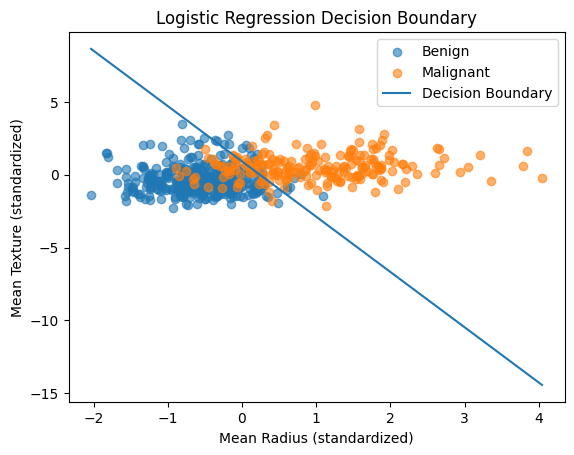

In [14]:
plt.figure()

X_all = np.vstack((X_train,X_test))

y_all = np.vstack((y_train,y_test))


benign = y_all[:, 0] == 0
malignant = y_all[:, 0] == 1

plt.scatter(X_all[benign, 0],X_all[benign, 1],label="Benign",alpha=0.6)

plt.scatter(X_all[malignant, 0],X_all[malignant, 1],label="Malignant",alpha=0.6)

x1_values = np.linspace(X_all[:, 0].min(),X_all[:, 0].max(),100)

x2_values = -(W[0, 0] * x1_values + b) / W[1, 0]


plt.plot(x1_values,x2_values,label="Decision Boundary")


plt.xlabel("Mean Radius (standardized)")
plt.ylabel("Mean Texture (standardized)")

plt.title("Logistic Regression Decision Boundary")

plt.legend()

plt.show()


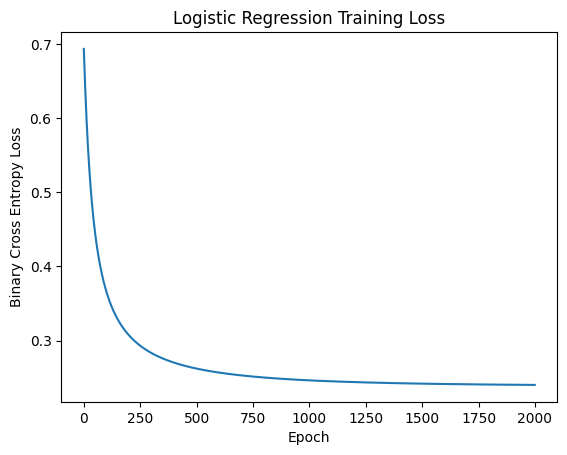

In [15]:
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Logistic Regression Training Loss")
plt.show()
